In [1]:
# Cell 1: Import libraries and load cleaned dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load cleaned data
df = pd.read_csv("data/materials_cleaned.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully
Dataset shape: (10, 18)


,rank,material_name,category,strength_mpa,weight_capacity_kg,biodegradability_score,co2_emission_score,recyclability_percent,cost_per_kg,co2_impact_index,cost_efficiency_index,material_suitability_score,scaled_strength,scaled_weight_capacity,scaled_biodegradability,scaled_co2,scaled_recyclability,scaled_cost
0,1,Recycled Corrugated Cardboard,Paper,35,5.0,90,1.20,85,65,0.084623,0.835618,0.650477,0.250000,0.444444,0.964912,0.117647,0.697674,0.105263
1,2,Molded Pulp Tray,Bio,30,4.0,88,0.95,90,70,0.054541,0.833660,0.619812,0.166667,0.333333,0.929825,0.044118,0.813953,0.157895
2,3,Kraft Paper,Pulp,25,3.0,85,1.00,80,55,0.084417,0.874419,0.589109,0.083333,0.222222,0.877193,0.058824,0.581395,0.000000
3,4,HDPE Recycled Plastic,Plastic,60,10.0,40,2.80,70,95,0.717853,0.509914,0.565673,0.666667,1.000000,0.087719,0.588235,0.348837,0.421053
4,5,Sugarcane Bagasse Box,Bio,32,3.5,89,1.10,88,90,0.073994,0.672338,0.558486,0.200000,0.277778,0.947368,0.088235,0.767442,0.368421


In [2]:
# Cell 2: Feature selection and target variables

# Input features (X)
feature_cols = [
    "strength_mpa",
    "weight_capacity_kg",
    "biodegradability_score",
    "recyclability_percent"
]

X = df[feature_cols]

# Targets
y_cost = df["cost_per_kg"]
y_co2 = df["co2_emission_score"]

print("Selected features:", feature_cols)
print("X shape:", X.shape)
print("y_cost shape:", y_cost.shape)
print("y_co2 shape:", y_co2.shape)

X.head()


Selected features: ['strength_mpa', 'weight_capacity_kg', 'biodegradability_score', 'recyclability_percent']
X shape: (10, 4)
y_cost shape: (10,)
y_co2 shape: (10,)


,strength_mpa,weight_capacity_kg,biodegradability_score,recyclability_percent
0,35,5.0,90,85
1,30,4.0,88,90
2,25,3.0,85,80
3,60,10.0,40,70
4,32,3.5,89,88


In [ ]:
## Dataset Preparation
Selected relevant material features and defined target variables for cost and CO₂ prediction.

In [3]:
# Cell 3: Train-test split and feature scaling

# Split data (80% train, 20% test)
X_train, X_test, y_cost_train, y_cost_test = train_test_split(
    X, y_cost, test_size=0.2, random_state=42
)

_, _, y_co2_train, y_co2_test = train_test_split(
    X, y_co2, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied successfully")


Training samples: 8
Testing samples: 2
Scaling applied successfully


In [ ]:
## Model Development
Trained Random Forest and XGBoost regression models for cost and CO₂ estimation.

In [4]:
# Cell 4: Random Forest model for COST prediction

# Initialize model
rf_cost = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_cost.fit(X_train_scaled, y_cost_train)

# Predict on test set
y_cost_pred = rf_cost.predict(X_test_scaled)

print("Random Forest model trained for COST prediction")
print("Predicted cost values:", y_cost_pred)


Random Forest model trained for COST prediction
Predicted cost values: [122.1   85.35]


In [ ]:
## Model Evaluation
Evaluated models using RMSE, MAE, and R² metrics and validated predictions visually.

In [5]:
# Cell 5: Evaluation metrics for COST prediction

rmse_cost = np.sqrt(mean_squared_error(y_cost_test, y_cost_pred))
mae_cost = mean_absolute_error(y_cost_test, y_cost_pred)
r2_cost = r2_score(y_cost_test, y_cost_pred)

print("COST MODEL PERFORMANCE (Random Forest)")
print("RMSE:", rmse_cost)
print("MAE :", mae_cost)
print("R²  :", r2_cost)


COST MODEL PERFORMANCE (Random Forest)
RMSE: 22.517021339422318
MAE : 21.625
R²  : 0.68311484375


In [6]:
# Cell 6: Random Forest model for CO₂ prediction

rf_co2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_co2.fit(X_train_scaled, y_co2_train)

y_co2_pred = rf_co2.predict(X_test_scaled)

print("Random Forest model trained for CO₂ prediction")
print("Predicted CO₂ values:", y_co2_pred)


Random Forest model trained for CO₂ prediction
Predicted CO₂ values: [3.166 1.112]


In [7]:
# Cell 7: Evaluation metrics for CO₂ prediction

rmse_co2 = np.sqrt(mean_squared_error(y_co2_test, y_co2_pred))
mae_co2 = mean_absolute_error(y_co2_test, y_co2_pred)
r2_co2 = r2_score(y_co2_test, y_co2_pred)

print("CO₂ MODEL PERFORMANCE (Random Forest)")
print("RMSE:", rmse_co2)
print("MAE :", mae_co2)
print("R²  :", r2_co2)


CO₂ MODEL PERFORMANCE (Random Forest)
RMSE: 0.26248809496813413
MAE : 0.2480000000000001
R²  : 0.9576163014225296


In [8]:
# Cell 8: XGBoost model for COST prediction

xgb_cost = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_cost.fit(X_train_scaled, y_cost_train)

y_cost_pred_xgb = xgb_cost.predict(X_test_scaled)

print("XGBoost model trained for COST prediction")


XGBoost model trained for COST prediction


In [9]:
# Cell 9: Evaluation metrics for XGBoost COST model

rmse_cost_xgb = np.sqrt(mean_squared_error(y_cost_test, y_cost_pred_xgb))
mae_cost_xgb = mean_absolute_error(y_cost_test, y_cost_pred_xgb)
r2_cost_xgb = r2_score(y_cost_test, y_cost_pred_xgb)

print("COST MODEL PERFORMANCE (XGBoost)")
print("RMSE:", rmse_cost_xgb)
print("MAE :", mae_cost_xgb)
print("R²  :", r2_cost_xgb)


COST MODEL PERFORMANCE (XGBoost)
RMSE: 9.977595216836328
MAE : 9.97408676147461
R²  : 0.9377797245979309


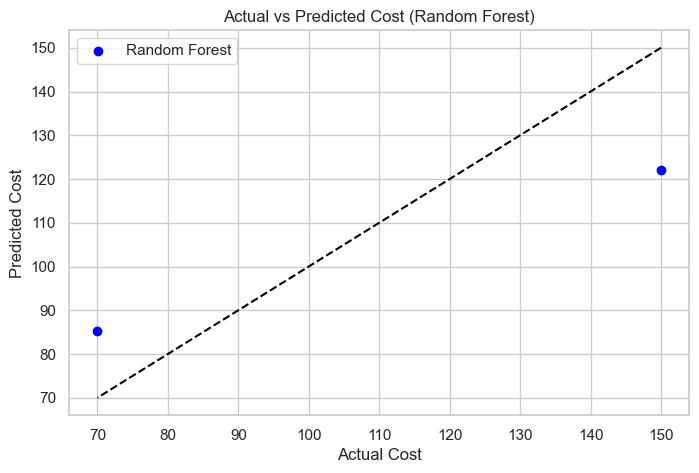

In [10]:
# Cell 10: Visualization - Actual vs Predicted Cost

plt.scatter(y_cost_test, y_cost_pred, color="blue", label="Random Forest")
plt.plot(y_cost_test, y_cost_test, color="black", linestyle="--")

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cost (Random Forest)")
plt.legend()
plt.show()


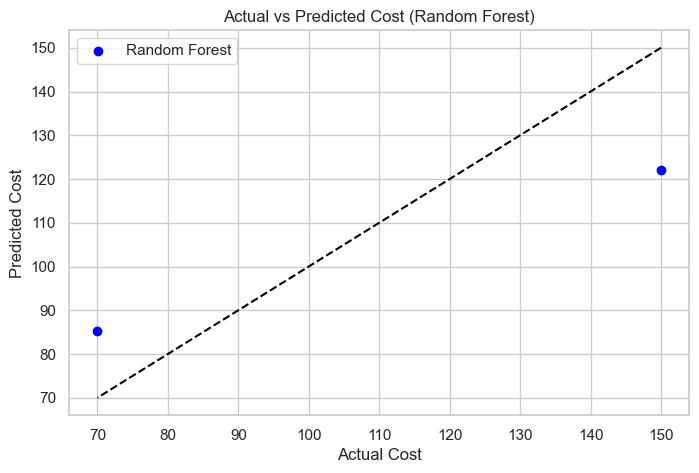

In [13]:
# Actual vs Predicted Cost (Random Forest)

plt.scatter(y_cost_test, y_cost_pred, color="blue", label="Random Forest")
plt.plot(y_cost_test, y_cost_test, color="black", linestyle="--")

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cost (Random Forest)")
plt.legend()

# Save graph
plt.savefig("documentation/cost_prediction_rf.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
## Material Recommendation
Generated an initial material suitability ranking based on predicted cost and CO₂ impact.


In [11]:
# Cell 11: Initial material ranking

df["predicted_cost"] = rf_cost.predict(scaler.transform(X))
df["predicted_co2"] = rf_co2.predict(scaler.transform(X))

# Lower cost + lower CO₂ = better score
df["material_score"] = (
    (1 - (df["predicted_cost"] / df["predicted_cost"].max())) +
    (1 - (df["predicted_co2"] / df["predicted_co2"].max()))
)

ranking = df[["material_name", "predicted_cost", "predicted_co2", "material_score"]] \
    .sort_values(by="material_score", ascending=False)

ranking


,material_name,predicted_cost,predicted_co2,material_score
2,Kraft Paper,68.10,1.038,1.156080
0,Recycled Corrugated Cardboard,72.40,1.141,1.092133
4,Sugarcane Bagasse Box,84.80,1.084,1.008475
1,Molded Pulp Tray,85.35,1.112,0.996077
5,Bamboo Fiber Box,97.50,0.939,0.947443
9,Cornstarch Biopolymer Film,115.75,1.883,0.531804
3,HDPE Recycled Plastic,98.70,2.503,0.492700
7,PLA Bioplastic,120.15,1.926,0.484126
8,Glass Bottle,122.10,3.166,0.115545
6,Aluminum Can,124.15,3.514,0.000000
